In [1]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

AUDIO_PATH = "C:/Users/felip/OneDrive/Documentos/power_trios/data/audio/hendrix/"

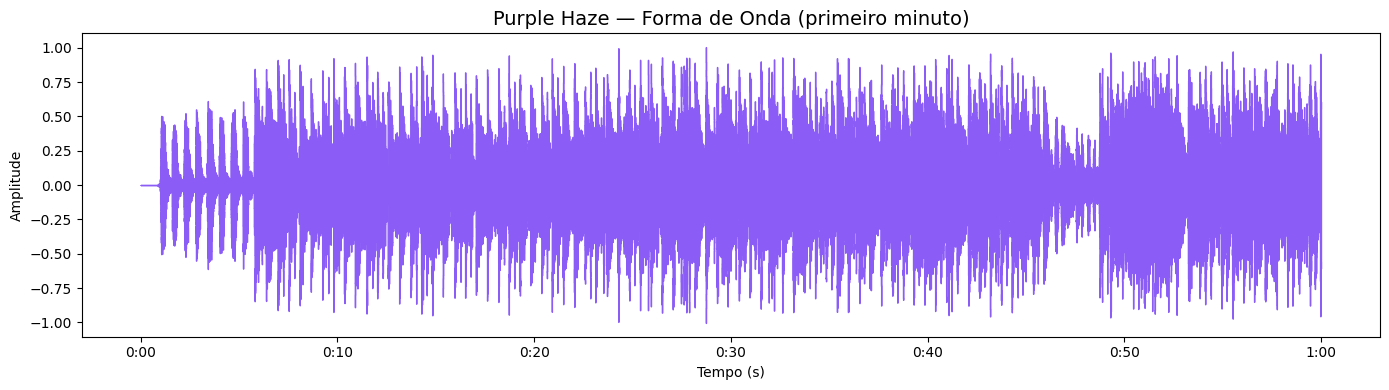

Duração carregada: 60.0s
Sample rate: 22050Hz


In [2]:
# Carregar o áudio
y, sr = librosa.load(AUDIO_PATH + "purple_haze.mp3", duration=60)

# Plotar a forma de onda
plt.figure(figsize=(14, 4))
librosa.display.waveshow(y, sr=sr, color="#8B5CF6")
plt.title("Purple Haze — Forma de Onda (primeiro minuto)", fontsize=14)
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

print(f"Duração carregada: {len(y)/sr:.1f}s")
print(f"Sample rate: {sr}Hz")

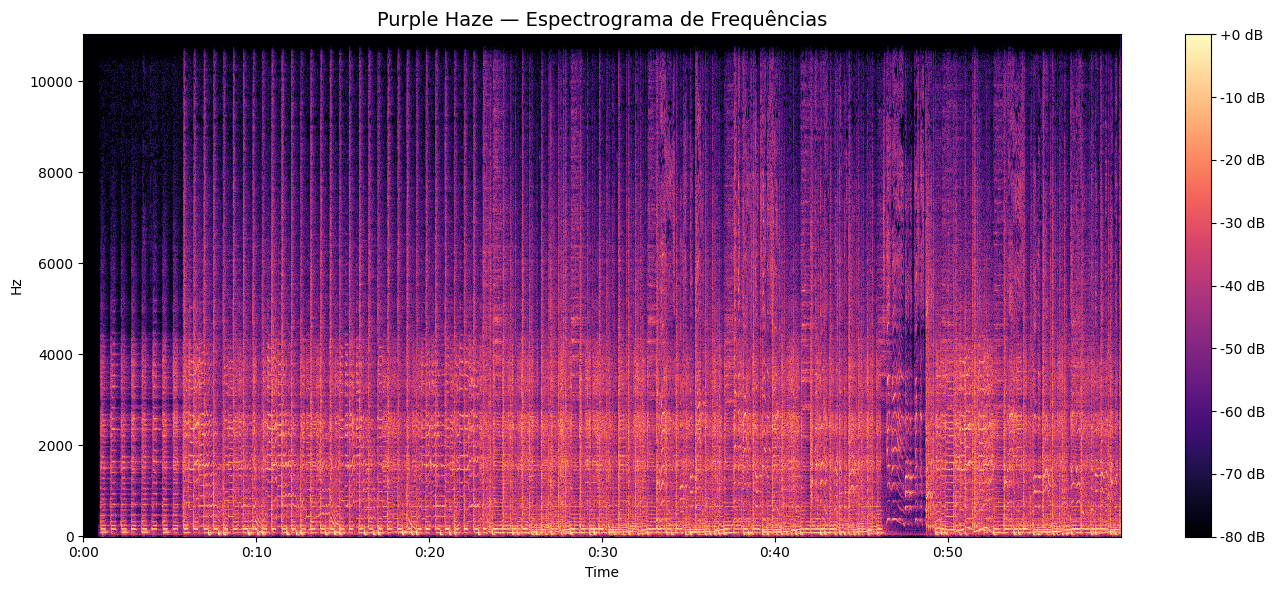

In [3]:
# Calcular espectrograma
D = librosa.stft(y)
DB = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(14, 6))
librosa.display.specshow(DB, sr=sr, x_axis="time", y_axis="hz", cmap="magma")
plt.colorbar(format="%+2.0f dB")
plt.title("Purple Haze — Espectrograma de Frequências", fontsize=14)
plt.tight_layout()
plt.show()

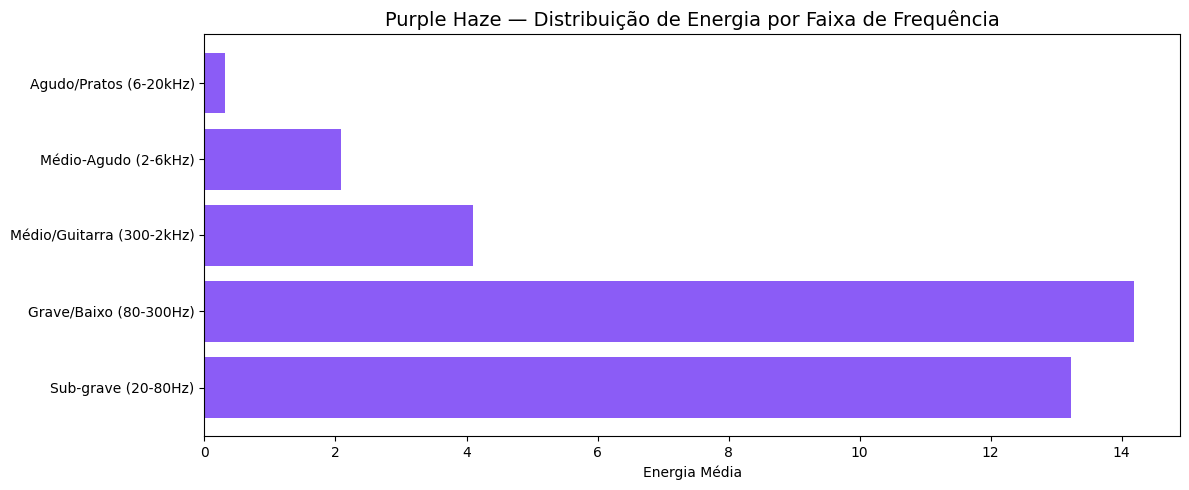

                    Faixa  Energia Média
      Sub-grave (20-80Hz)      13.230315
   Grave/Baixo (80-300Hz)      14.182724
Médio/Guitarra (300-2kHz)       4.093345
     Médio-Agudo (2-6kHz)       2.089450
   Agudo/Pratos (6-20kHz)       0.316194


In [4]:
# Dividir o espectro em regiões instrumentais
freqs = librosa.fft_frequencies(sr=sr)
magnitude = np.abs(D)

# Faixas de frequência
sub_bass   = (freqs >= 20)  & (freqs < 80)    # Sub-grave
bass       = (freqs >= 80)  & (freqs < 300)   # Grave (baixo)
midrange   = (freqs >= 300) & (freqs < 2000)  # Médio (guitarra rítmica)
high_mid   = (freqs >= 2000)& (freqs < 6000)  # Médio-agudo (guitarra solo)
high       = (freqs >= 6000)& (freqs < 20000) # Agudo (pratos, ataque)

energy = {
    "Sub-grave (20-80Hz)":      magnitude[sub_bass].mean(),
    "Grave/Baixo (80-300Hz)":   magnitude[bass].mean(),
    "Médio/Guitarra (300-2kHz)":magnitude[midrange].mean(),
    "Médio-Agudo (2-6kHz)":     magnitude[high_mid].mean(),
    "Agudo/Pratos (6-20kHz)":   magnitude[high].mean(),
}

df_energy = pd.DataFrame(list(energy.items()), columns=["Faixa", "Energia Média"])

plt.figure(figsize=(12, 5))
bars = plt.barh(df_energy["Faixa"], df_energy["Energia Média"], color="#8B5CF6")
plt.title("Purple Haze — Distribuição de Energia por Faixa de Frequência", fontsize=14)
plt.xlabel("Energia Média")
plt.tight_layout()
plt.show()

print(df_energy.to_string(index=False))

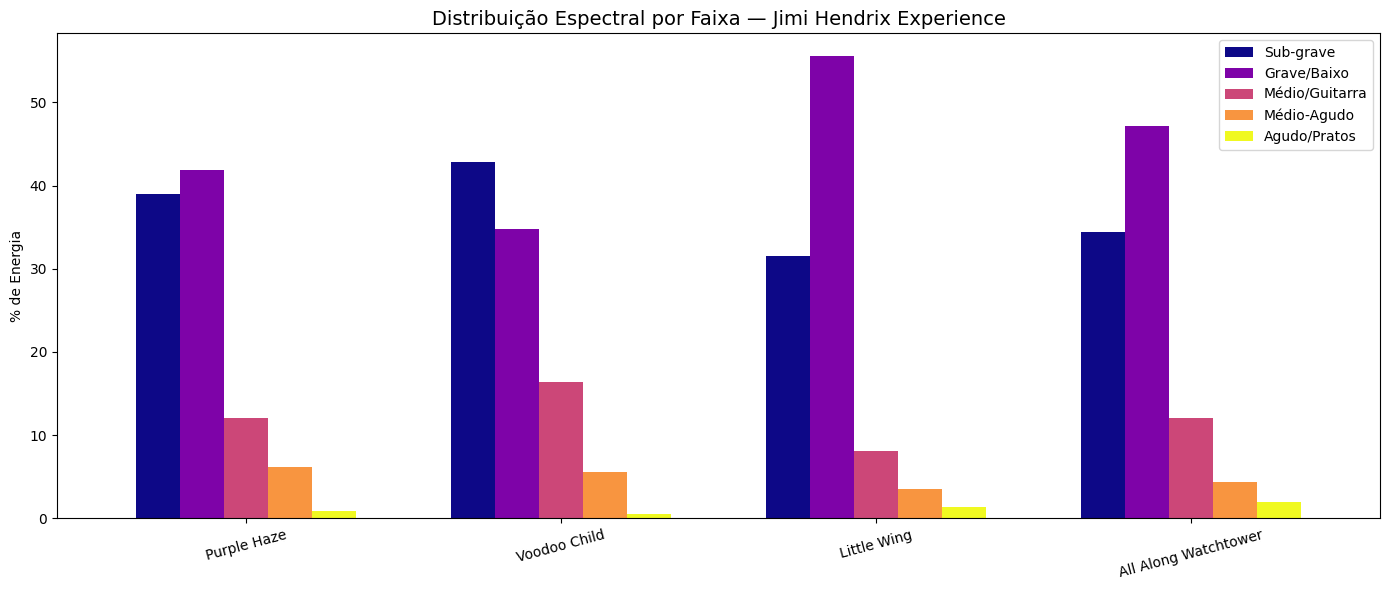

                      Sub-grave  Grave/Baixo  Médio/Guitarra  Médio-Agudo  Agudo/Pratos
Faixa                                                                                  
Purple Haze           39.000000    41.799999       12.100000          6.2           0.9
Voodoo Child          42.799999    34.700001       16.299999          5.6           0.6
Little Wing           31.500000    55.500000        8.100000          3.6           1.3
All Along Watchtower  34.400002    47.200001       12.000000          4.4           2.0


In [5]:
# Comparação entre todas as faixas
faixas = {
    "Purple Haze":           "purple_haze.mp3",
    "Voodoo Child":          "voodoo_child.mp3",
    "Little Wing":           "littlewing.mp3",
    "All Along Watchtower":  "all_allong_the_watchtower.mp3",
}

resultados = []

for nome, arquivo in faixas.items():
    y_f, sr_f = librosa.load(AUDIO_PATH + arquivo, duration=60)
    D_f = librosa.stft(y_f)
    mag = np.abs(D_f)
    freqs_f = librosa.fft_frequencies(sr=sr_f)
    
    resultados.append({
        "Faixa":              nome,
        "Sub-grave":          mag[(freqs_f >= 20)  & (freqs_f < 80)].mean(),
        "Grave/Baixo":        mag[(freqs_f >= 80)  & (freqs_f < 300)].mean(),
        "Médio/Guitarra":     mag[(freqs_f >= 300) & (freqs_f < 2000)].mean(),
        "Médio-Agudo":        mag[(freqs_f >= 2000)& (freqs_f < 6000)].mean(),
        "Agudo/Pratos":       mag[(freqs_f >= 6000)& (freqs_f < 20000)].mean(),
    })

df_comp = pd.DataFrame(resultados).set_index("Faixa")

# Normalizar para comparação
df_norm = df_comp.div(df_comp.sum(axis=1), axis=0) * 100

# Plotar
ax = df_norm.plot(kind="bar", figsize=(14, 6), colormap="plasma", width=0.7)
plt.title("Distribuição Espectral por Faixa — Jimi Hendrix Experience", fontsize=14)
plt.xlabel("")
plt.ylabel("% de Energia")
plt.xticks(rotation=15)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(df_norm.round(1).to_string())

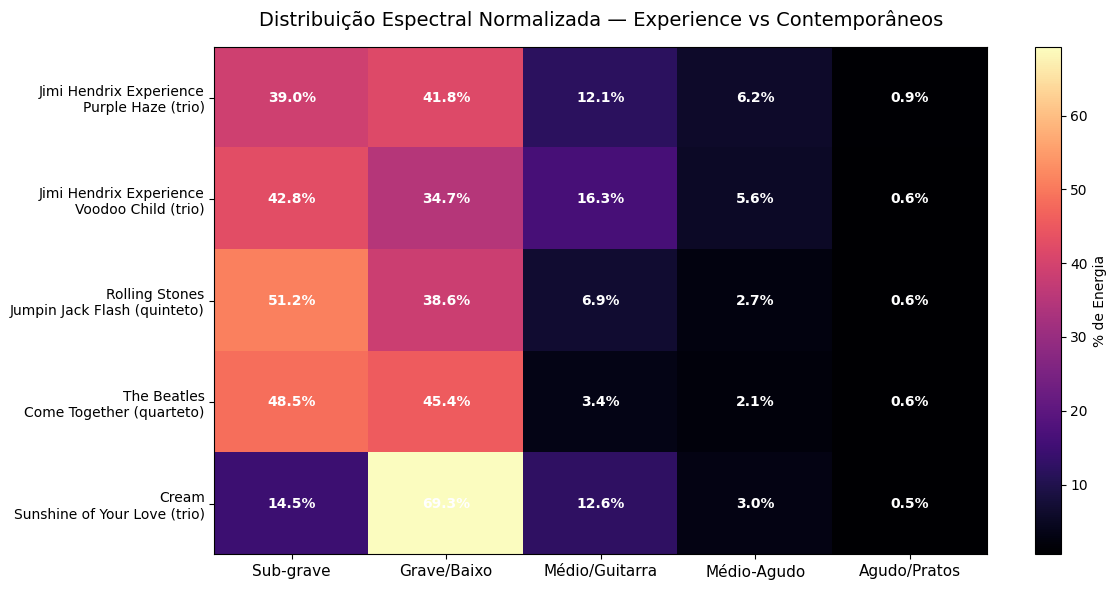

                                              Sub-grave  Grave/Baixo  Médio/Guitarra  Médio-Agudo  Agudo/Pratos
Banda/Faixa                                                                                                    
Jimi Hendrix Experience\nPurple Haze (trio)   39.000000    41.799999       12.100000          6.2           0.9
Jimi Hendrix Experience\nVoodoo Child (trio)  42.799999    34.700001       16.299999          5.6           0.6
Rolling Stones\nJumpin Jack Flash (quinteto)  51.200001    38.599998        6.900000          2.7           0.6
The Beatles\nCome Together (quarteto)         48.500000    45.400002        3.400000          2.1           0.6
Cream\nSunshine of Your Love (trio)           14.500000    69.300003       12.600000          3.0           0.5


In [7]:
COMP_PATH = "C:/Users/felip/OneDrive/Documentos/power_trios/data/audio/comparacao/"

comparacao = {
    "Jimi Hendrix Experience\nPurple Haze (trio)":        (AUDIO_PATH, "purple_haze.mp3"),
    "Jimi Hendrix Experience\nVoodoo Child (trio)":       (AUDIO_PATH, "voodoo_child.mp3"),
    "Rolling Stones\nJumpin Jack Flash (quinteto)":       (COMP_PATH,  "jumpin_jack_flash.mp3"),
    "The Beatles\nCome Together (quarteto)":              (COMP_PATH,  "come_together.mp3"),
    "Cream\nSunshine of Your Love (trio)":                (COMP_PATH,  "sunshine_of_your_love.mp3"),
}

resultados_comp = []

for nome, (path, arquivo) in comparacao.items():
    y_c, sr_c = librosa.load(path + arquivo, duration=60)
    D_c = librosa.stft(y_c)
    mag_c = np.abs(D_c)
    freqs_c = librosa.fft_frequencies(sr=sr_c)

    resultados_comp.append({
        "Banda/Faixa":    nome,
        "Sub-grave":      mag_c[(freqs_c >= 20)  & (freqs_c < 80)].mean(),
        "Grave/Baixo":    mag_c[(freqs_c >= 80)  & (freqs_c < 300)].mean(),
        "Médio/Guitarra": mag_c[(freqs_c >= 300) & (freqs_c < 2000)].mean(),
        "Médio-Agudo":    mag_c[(freqs_c >= 2000)& (freqs_c < 6000)].mean(),
        "Agudo/Pratos":   mag_c[(freqs_c >= 6000)& (freqs_c < 20000)].mean(),
    })

df_final = pd.DataFrame(resultados_comp).set_index("Banda/Faixa")

# Normalizar cada linha para 100%
df_pct = df_final.div(df_final.sum(axis=1), axis=0) * 100

# Plotar heatmap normalizado
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(df_pct.values, aspect="auto", cmap="magma")

ax.set_xticks(range(len(df_pct.columns)))
ax.set_xticklabels(df_pct.columns, fontsize=11)
ax.set_yticks(range(len(df_pct.index)))
ax.set_yticklabels(df_pct.index, fontsize=10)

for i in range(len(df_pct.index)):
    for j in range(len(df_pct.columns)):
        ax.text(j, i, f"{df_pct.values[i,j]:.1f}%",
                ha="center", va="center", color="white", fontsize=10, fontweight="bold")

plt.colorbar(im, ax=ax, label="% de Energia")
plt.title("Distribuição Espectral Normalizada — Experience vs Contemporâneos", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

print(df_pct.round(1).to_string())